In [72]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)

matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'text.usetex': True,
    'font.family': 'serif',
    'pgf.rcfonts': False,
})

def read_files(files):
    data = []
    for f in files:
        data += [pd.read_csv(f, sep=',', skipinitialspace=True)]
    return data

[wide, thin] = read_files(['data/PQ.csv', 'data/PQ_thin.csv'])
[l_wide, l_thin] = read_files(['data/lenght_wide.csv', 'data/lenght_thin.csv'])

press = [df['P'] for df in [wide, thin]]
time = [df['t'] for df in [wide, thin]]
pl = [df['P'] for df in [l_wide, l_thin]]
lenght = [df['l'] for df in [l_wide, l_thin]]
Q = [1 / t * 1e3 for t in time]

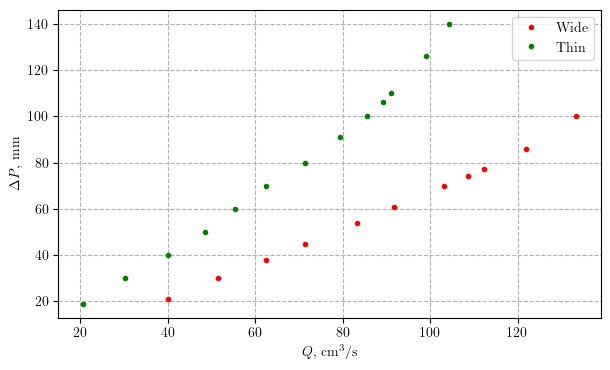

In [73]:
colors = ['red', 'green']
labels = ['Wide', 'Thin']

plt.figure(figsize=(7, 4))

for i in range(press.__len__()):
    plt.errorbar(Q[i], press[i], fmt=f'{colors[i][0]}.', label=labels[i])

plt.xlabel('$Q$, cm$^3$/s')
plt.ylabel('$\Delta P$, mm')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/graph.pdf')

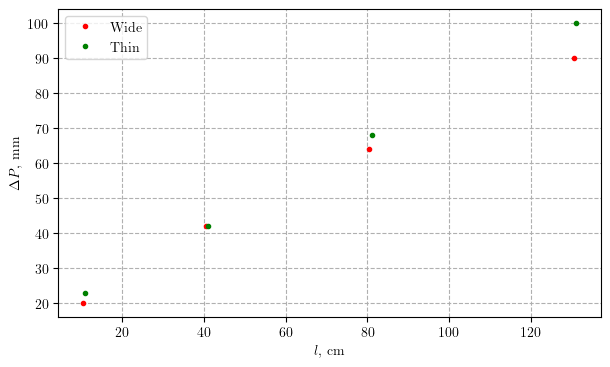

In [74]:
colors = ['red', 'green']
labels = ['Wide', 'Thin']

plt.figure(figsize=(7, 4))

for i in range(lenght.__len__()):
    plt.errorbar(lenght[i], pl[i], fmt=f'{colors[i][0]}.', label=labels[i])

plt.xlabel('$l$, cm')
plt.ylabel('$\Delta P$, mm')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/lenght.pdf')

In [77]:
import re

for df in [wide, thin]:
    df['Q'] = 1e3 / df['t']
    tex_content = df.to_latex(index=False, escape=False, position='h!', float_format='%.1f')

    re_borders = re.compile(r"begin\{tabular\}\{([^\}]+)\}")
    borders = re_borders.findall(tex_content)[0]
    borders = '|'.join(list(borders))
    tex_content = re_borders.sub("begin{tabular}{" + borders + "}", tex_content)

    print(tex_content)

\begin{table}[h!]
\centering
\begin{tabular}{r|r|r}
\toprule
  P &    t &     Q \\
\midrule
 21 & 25.0 &  40.0 \\
 38 & 16.0 &  62.5 \\
 54 & 12.0 &  83.3 \\
 86 &  8.2 & 122.0 \\
100 &  7.5 & 133.3 \\
 30 & 19.4 &  51.5 \\
 45 & 14.0 &  71.4 \\
 61 & 10.9 &  91.7 \\
 70 &  9.7 & 103.1 \\
 74 &  9.2 & 108.7 \\
 77 &  8.9 & 112.4 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\begin{tabular}{r|r|r}
\toprule
  P &    t &     Q \\
\midrule
 19 & 48.5 &  20.6 \\
 30 & 33.0 &  30.3 \\
 40 & 25.0 &  40.0 \\
 50 & 20.6 &  48.5 \\
 60 & 18.1 &  55.2 \\
 70 & 16.0 &  62.5 \\
 80 & 14.0 &  71.4 \\
 91 & 12.6 &  79.4 \\
100 & 11.7 &  85.5 \\
110 & 11.0 &  90.9 \\
106 & 11.2 &  89.3 \\
126 & 10.1 &  99.0 \\
140 &  9.6 & 104.2 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_4829/939982027.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex_content = df.to_latex(index=False, escape=False, position='h!', float_format='%.1f')
